# Dogłębna analiza danych (EDA)
Ten notatnik analizuje zbiór `idanbaru/annotated-potholes-with-severity-levels`, skupiając się na:
- liczbie adnotacji i obrazów,
- rozkładzie poziomów ważności (`severity`),
- liczbie dziur na obraz,
- wymiarach i jakości obwiedni (`bboxes`),
- przykładowych obrazach z adnotacjami.

In [5]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2

sys.path.append(os.path.abspath(os.path.join('..')))
from src.data_utils import parse_xmls

# Try multiple approaches to find/load dataset
PATH = None

# Approach 1: Check common local paths
local_paths = [
    os.path.expanduser("~/.cache/kagglehub/datasets/idanbaru/annotated-potholes-with-severity-levels/versions/1"),
    os.path.expanduser("~/kagglehub/datasets/idanbaru/annotated-potholes-with-severity-levels"),
    "./data/potholes",
    "../data/potholes",
]

for p in local_paths:
    if os.path.exists(p) and os.path.isdir(os.path.join(p, 'images')) and os.path.isdir(os.path.join(p, 'annotations')):
        PATH = p
        break

# Approach 2: If not found locally, try kagglehub (with error handling)
if PATH is None:
    try:
        import kagglehub
        print("Downloading dataset from Kaggle...")
        PATH = kagglehub.dataset_download("idanbaru/annotated-potholes-with-severity-levels")
    except ImportError as e:
        print(f"Warning: kagglehub import failed ({e}). Please ensure dataset is available at one of these paths:")
        for p in local_paths:
            print(f"  {p}")
        raise

if not os.path.exists(PATH):
    raise FileNotFoundError(f"Dataset not found at {PATH}")

print(f"Loading dataset from: {PATH}")
df = parse_xmls(PATH)

severity_map = {1: 'Minor', 2: 'Medium', 3: 'Major'}
df['severity_name'] = df['label'].map(severity_map)
df['width'] = df['xmax'] - df['xmin']
df['height'] = df['ymax'] - df['ymin']
df['area'] = df['width'] * df['height']
df['aspect_ratio'] = df['width'] / df['height'].replace(0, np.nan)
df['bbox_area_ratio'] = np.nan
df['x_center'] = (df['xmin'] + df['xmax']) / 2
df['y_center'] = (df['ymin'] + df['ymax']) / 2

Loading dataset from: C:\Users\Milosz/.cache/kagglehub/datasets/idanbaru/annotated-potholes-with-severity-levels/versions/1


In [6]:
image_info = []
for file_path in sorted(df['file'].unique()):
    img = cv2.imread(file_path)
    if img is None:
        image_info.append({'file': file_path, 'img_width': np.nan, 'img_height': np.nan})
        continue
    h, w = img.shape[:2]
    image_info.append({'file': file_path, 'img_width': w, 'img_height': h})

image_meta = pd.DataFrame(image_info)
df = df.merge(image_meta, on='file', how='left')
df['bbox_area_ratio'] = df['area'] / (df['img_width'] * df['img_height'])

print('Liczba adnotacji:', len(df))
print('Liczba unikalnych obrazów:', df['file'].nunique())
print('Rozkład levela severity:')
print(df['severity_name'].value_counts().reindex(['Minor', 'Medium', 'Major']))
print('\nStatystyki liczby dziur na obraz:')
print(df.groupby('file').size().describe())
print('\nLiczba obrazów, których wczytanie się nie powiodło:', df['img_width'].isna().sum())
print('Liczba adnotacji o zerowej szerokości lub wysokości:', ((df['width'] <= 0) | (df['height'] <= 0)).sum())

Liczba adnotacji: 1887
Liczba unikalnych obrazów: 716
Rozkład levela severity:
severity_name
Minor     418
Medium    869
Major     600
Name: count, dtype: int64

Statystyki liczby dziur na obraz:
count    716.000000
mean       2.635475
std        2.782025
min        1.000000
25%        1.000000
50%        2.000000
75%        3.000000
max       23.000000
dtype: float64

Liczba obrazów, których wczytanie się nie powiodło: 115
Liczba adnotacji o zerowej szerokości lub wysokości: 1


## Podstawowe wykresy rozkładów
Pokażemy rozkład `severity`, liczbę dziur na obraz oraz rozkłady rozmiaru obwiedni.

C:\Users\Milosz\AppData\Local\Temp\ipykernel_1560\1059548354.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='severity_name', order=['Minor', 'Medium', 'Major'], palette='magma')


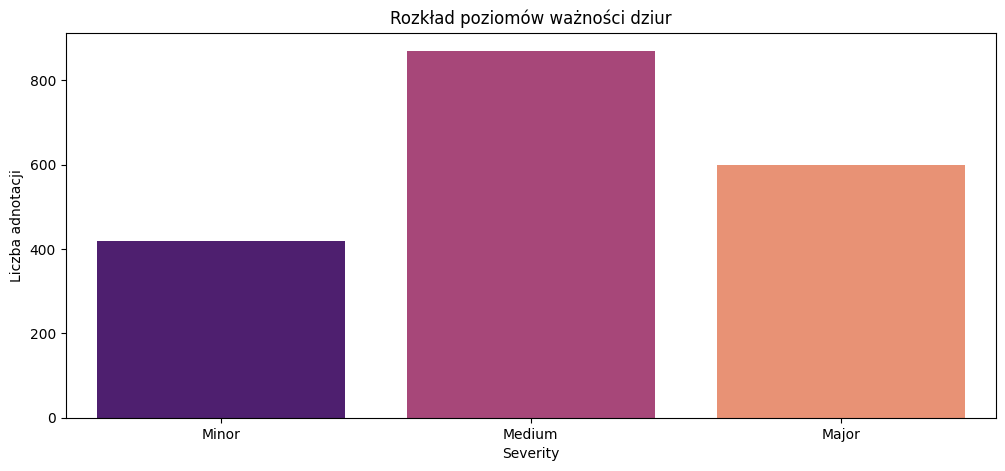

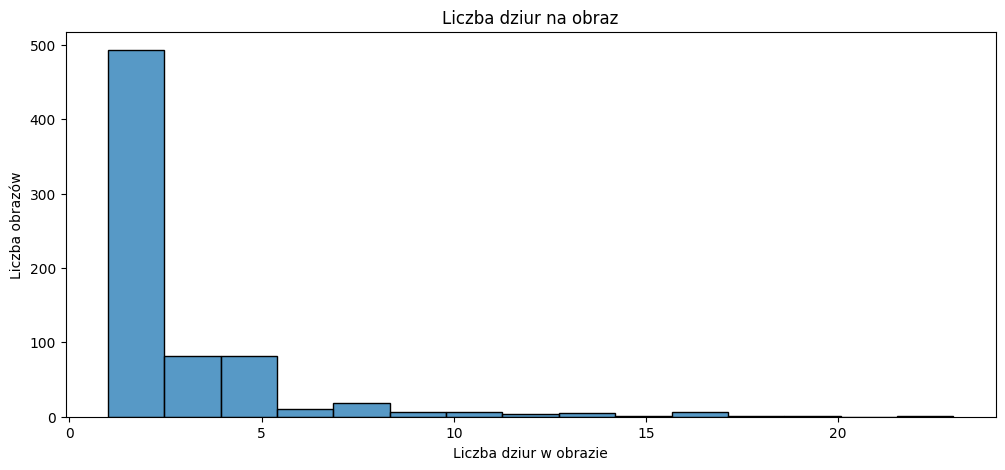

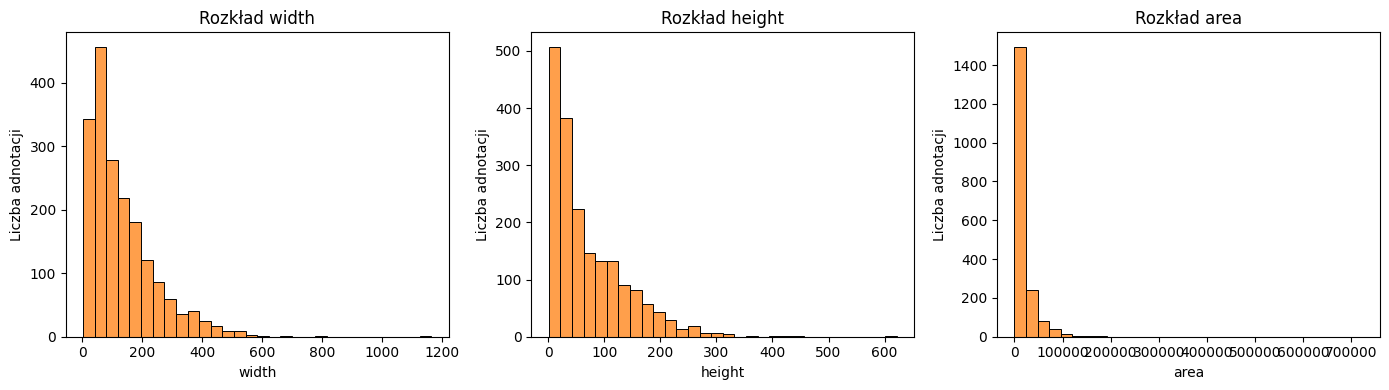

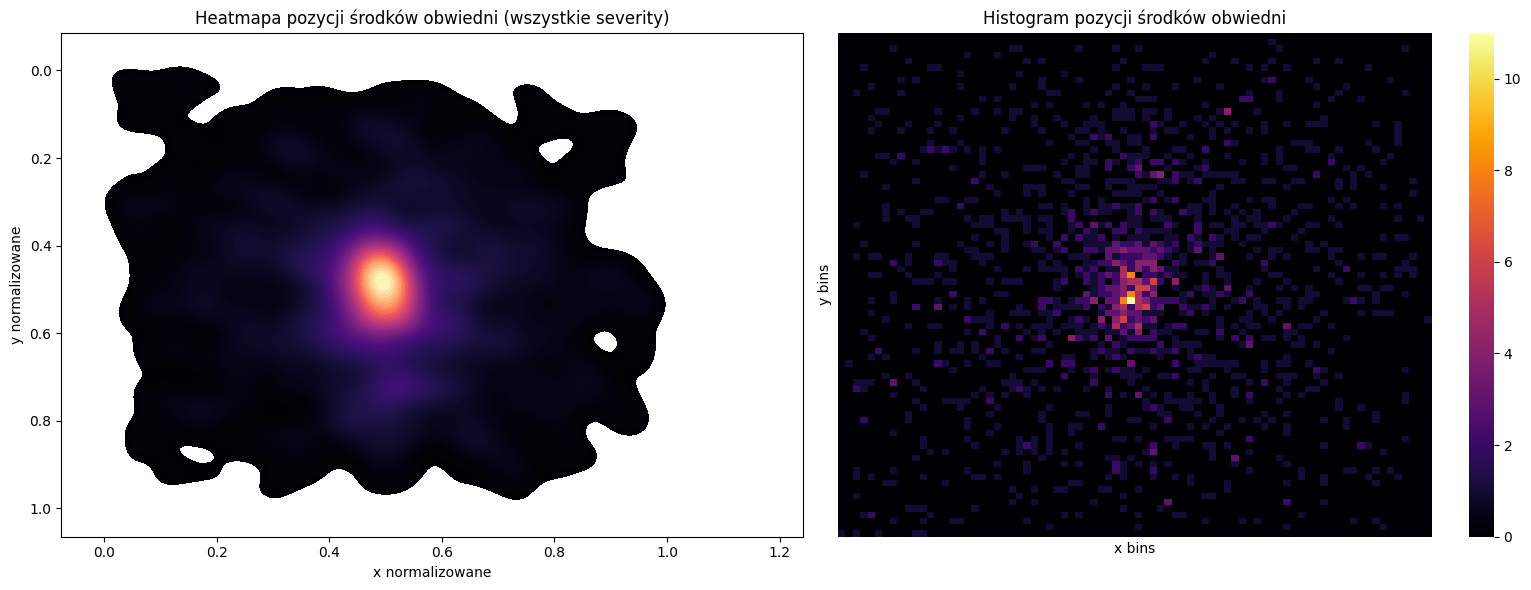

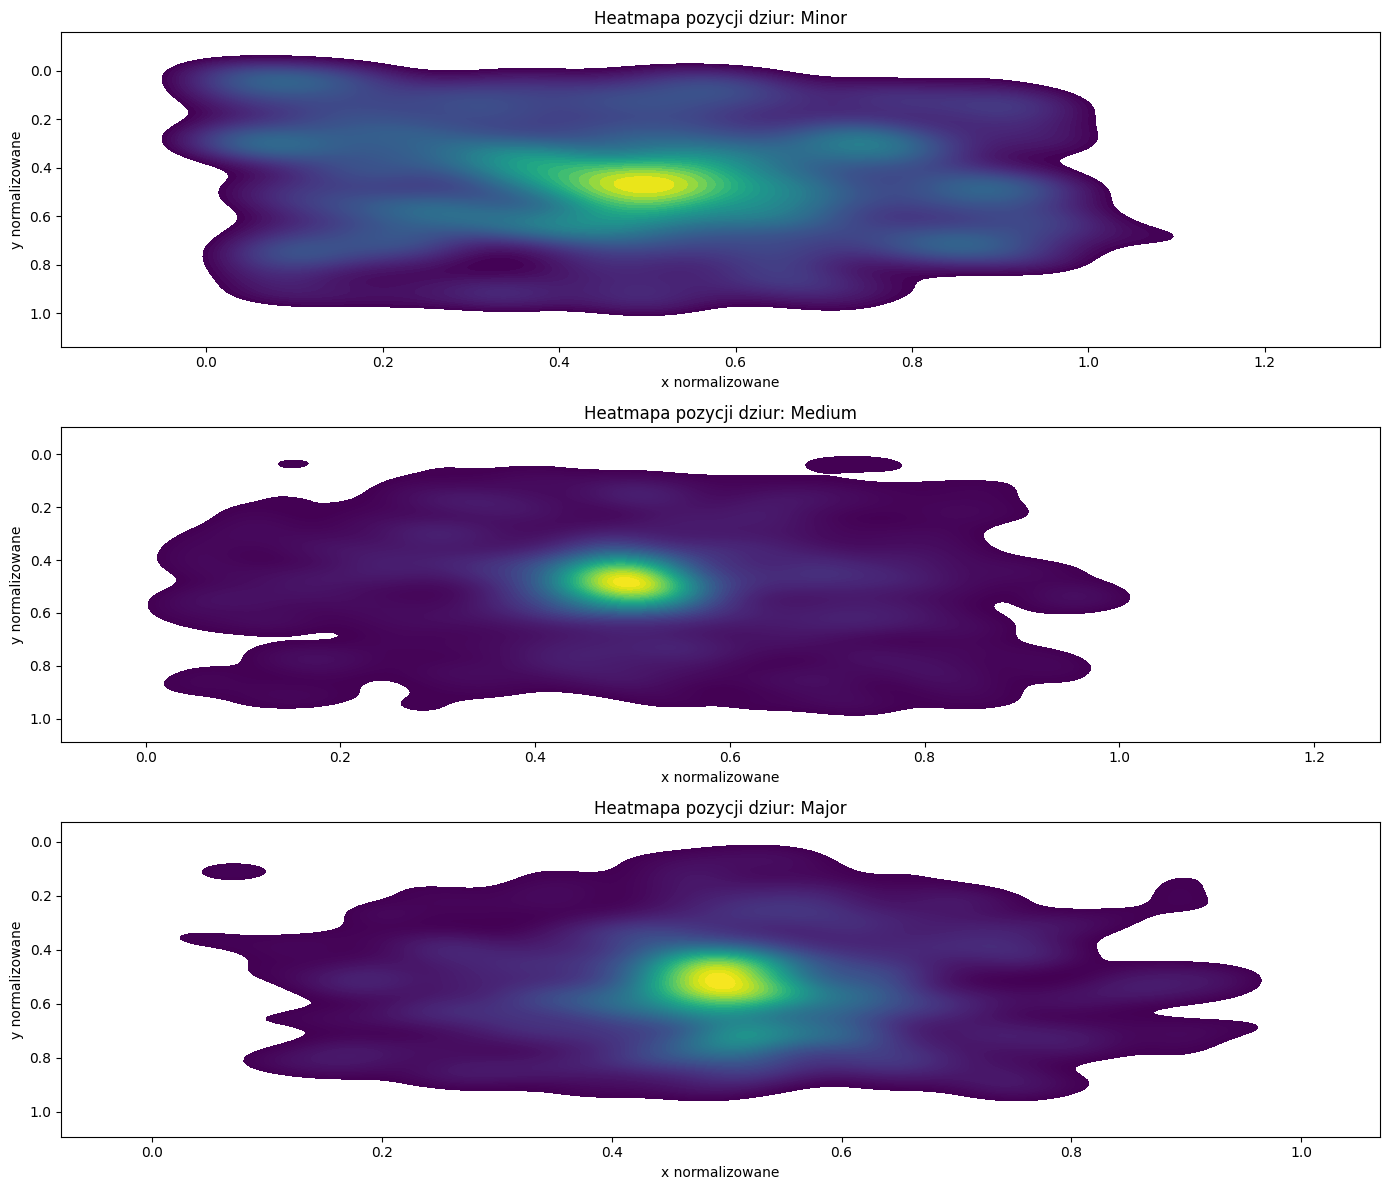

In [7]:
plt.figure(figsize=(12, 5))
sns.countplot(data=df, x='severity_name', order=['Minor', 'Medium', 'Major'], palette='magma')
plt.title('Rozkład poziomów ważności dziur')
plt.xlabel('Severity')
plt.ylabel('Liczba adnotacji')
plt.show()

plt.figure(figsize=(12, 5))
counts = df.groupby('file').size().rename('objects')
sns.histplot(counts, bins=15, kde=False, color='tab:blue')
plt.title('Liczba dziur na obraz')
plt.xlabel('Liczba dziur w obrazie')
plt.ylabel('Liczba obrazów')
plt.show()

plt.figure(figsize=(14, 4))
for idx, col in enumerate(['width', 'height', 'area']):
    plt.subplot(1, 3, idx + 1)
    sns.histplot(df[col].replace(0, np.nan).dropna(), bins=30, kde=False, color='tab:orange')
    plt.title(f'Rozkład {col}')
    plt.xlabel(col)
    plt.ylabel('Liczba adnotacji')
plt.tight_layout()
plt.show()

plt.figure(figsize=(16, 6))
plt.subplot(1, 2, 1)
sns.kdeplot(
    x=df['x_center'] / df['img_width'],
    y=df['y_center'] / df['img_height'],
    fill=True,
    cmap='magma',
    levels=100,
    thresh=0.05,
    bw_adjust=0.5
)
plt.gca().invert_yaxis()
plt.title('Heatmapa pozycji środków obwiedni (wszystkie severity)')
plt.xlabel('x normalizowane')
plt.ylabel('y normalizowane')

plt.subplot(1, 2, 2)
heatmap, xedges, yedges = np.histogram2d(
    df['x_center'] / df['img_width'],
    df['y_center'] / df['img_height'],
    bins=80,
    range=[[0, 1], [0, 1]]
)
sns.heatmap(heatmap.T, cmap='inferno', cbar=True, xticklabels=False, yticklabels=False)
plt.gca().invert_yaxis()
plt.title('Histogram pozycji środków obwiedni')
plt.xlabel('x bins')
plt.ylabel('y bins')
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 12))
for i, severity in enumerate(['Minor', 'Medium', 'Major'], start=1):
    sub = df[df['severity_name'] == severity]
    plt.subplot(3, 1, i)
    sns.kdeplot(
        x=sub['x_center'] / sub['img_width'],
        y=sub['y_center'] / sub['img_height'],
        fill=True,
        cmap='viridis',
        levels=80,
        thresh=0.05,
        bw_adjust=0.6
    )
    plt.gca().invert_yaxis()
    plt.title(f'Heatmapa pozycji dziur: {severity}')
    plt.xlabel('x normalizowane')
    plt.ylabel('y normalizowane')
plt.tight_layout()
plt.show()

Przykłady adnotacji z zerową szerokością lub wysokością:


,file,xmin,ymin,xmax,ymax,width,height,label
1745,C:\Users\Milosz/.cache/kagglehub/datasets/idan...,128,56,140,56,12,0,2


C:\Users\Milosz\AppData\Local\Temp\ipykernel_1560\56705080.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='severity_name', y='area', order=['Minor', 'Medium', 'Major'], palette='viridis')


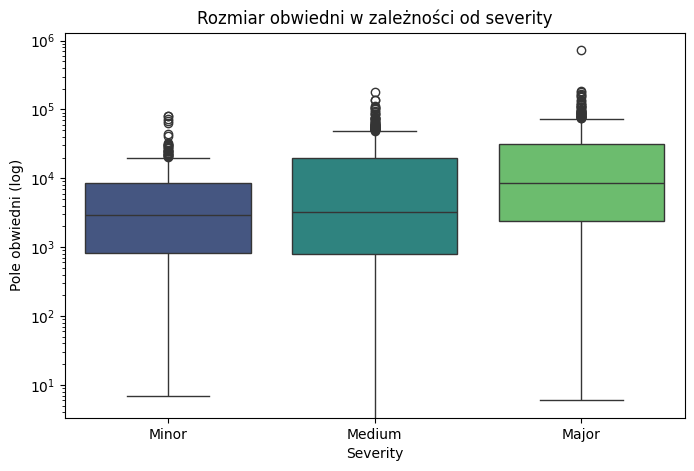

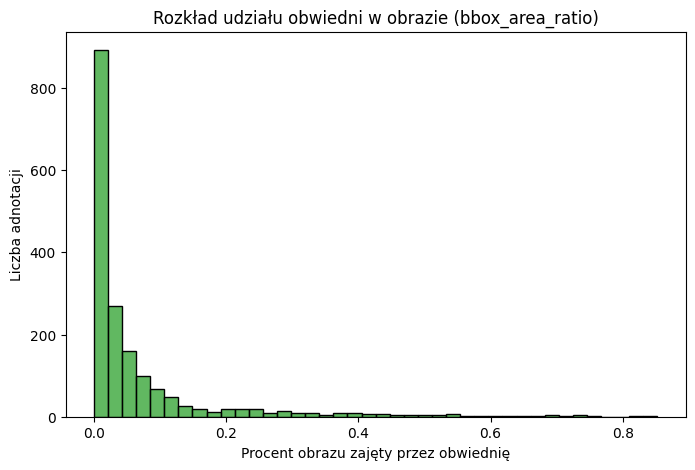

In [8]:
bad_boxes = df[(df['width'] <= 0) | (df['height'] <= 0)]
print('Przykłady adnotacji z zerową szerokością lub wysokością:')
display(bad_boxes[['file', 'xmin', 'ymin', 'xmax', 'ymax', 'width', 'height', 'label']].head(10))

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='severity_name', y='area', order=['Minor', 'Medium', 'Major'], palette='viridis')
plt.yscale('log')
plt.title('Rozmiar obwiedni w zależności od severity')
plt.xlabel('Severity')
plt.ylabel('Pole obwiedni (log)')
plt.show()

plt.figure(figsize=(8, 5))
sns.histplot(df['bbox_area_ratio'].dropna(), bins=40, kde=False, color='tab:green')
plt.title('Rozkład udziału obwiedni w obrazie (bbox_area_ratio)')
plt.xlabel('Procent obrazu zajęty przez obwiednię')
plt.ylabel('Liczba adnotacji')
plt.show()

## Przykłady obrazów z adnotacjami
Wyświetlimy wybrane obrazy z największą liczbą dziur oraz losowo wybrane przykłady różnych poziomów `severity`.

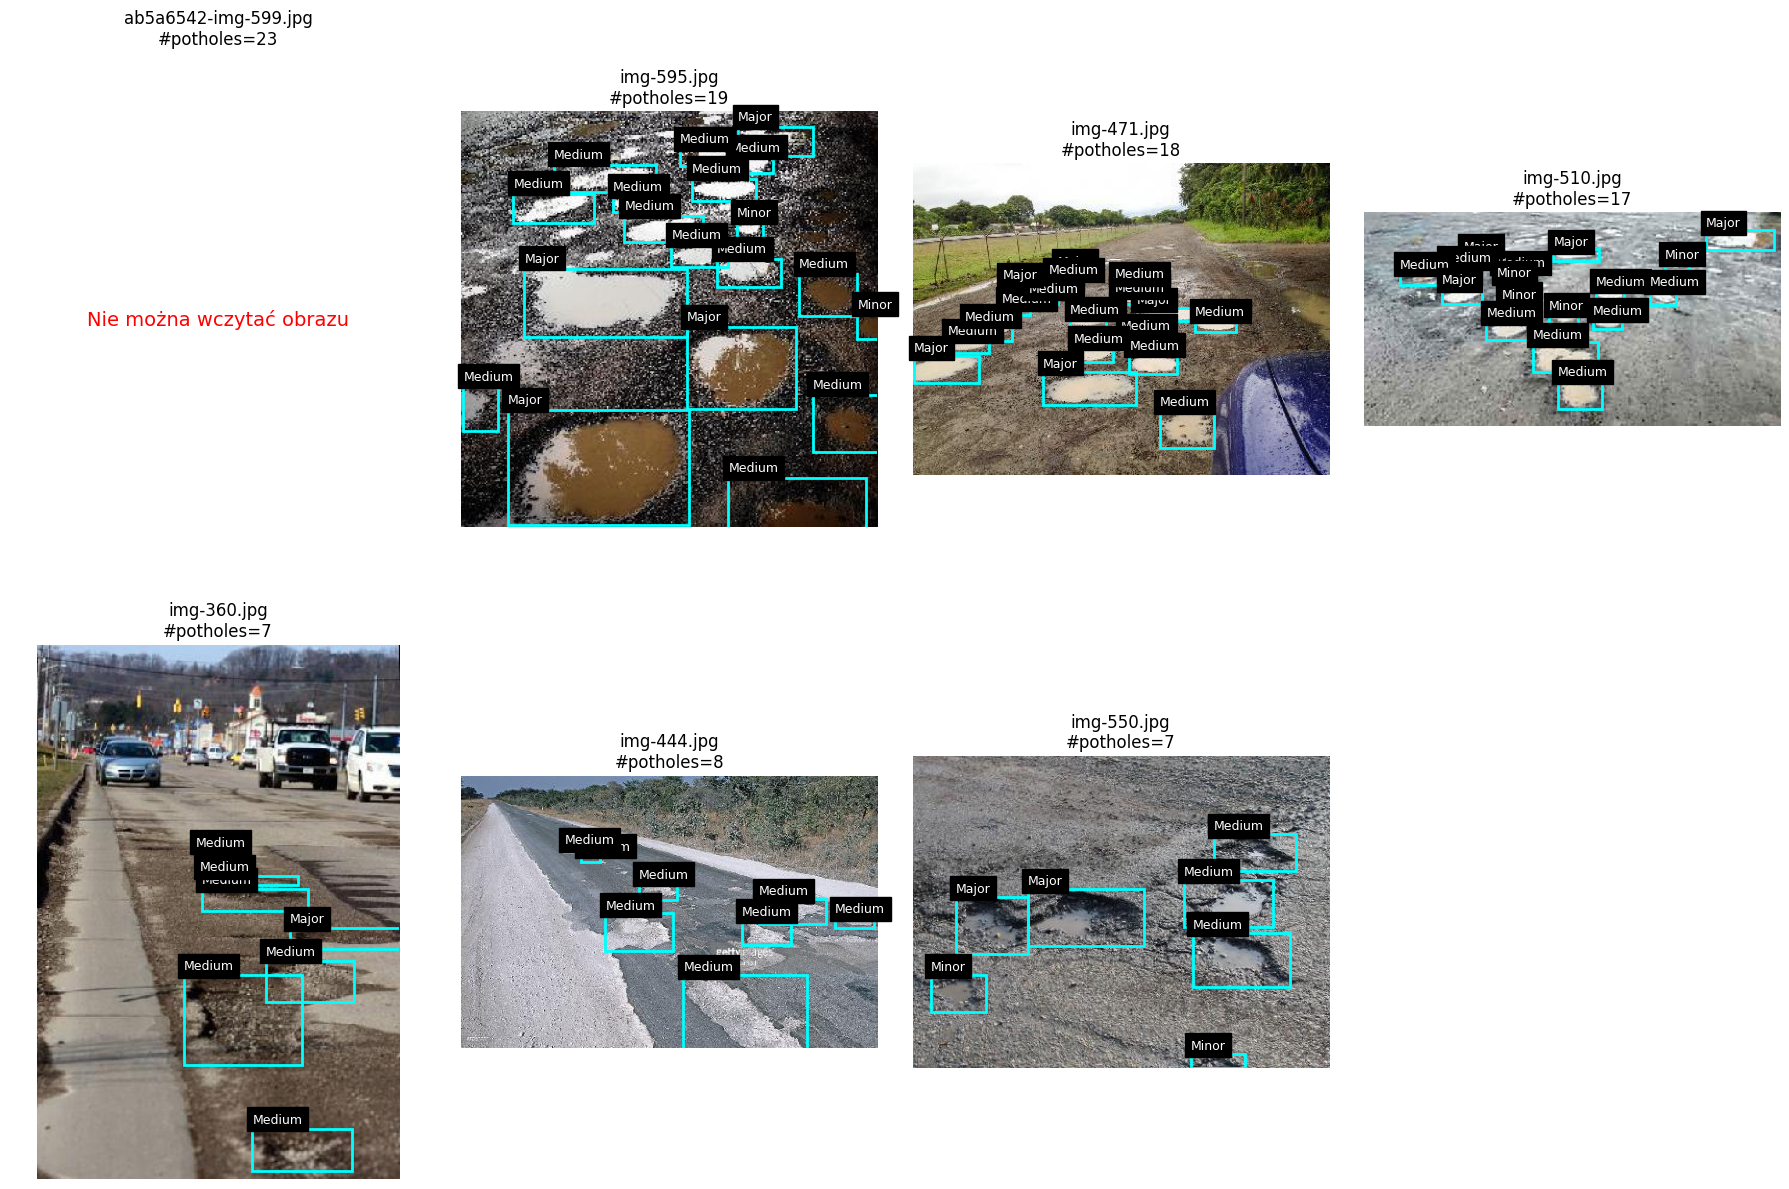

In [9]:
def draw_annotations(file_path, annotations, ax):
    img = cv2.imread(file_path)
    if img is None:
        ax.text(0.5, 0.5, 'Nie można wczytać obrazu', ha='center', va='center', fontsize=14, color='red')
        ax.axis('off')
        return
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    ax.imshow(img)
    for _, row in annotations.iterrows():
        rect = plt.Rectangle((row['xmin'], row['ymin']), row['width'], row['height'], edgecolor='cyan', facecolor='none', linewidth=2)
        ax.add_patch(rect)
        ax.text(row['xmin'], row['ymin'] - 5, row['severity_name'], color='white', fontsize=9, backgroundcolor='black')
    ax.axis('off')

top_files = df.groupby('file').size().sort_values(ascending=False).head(4).index.tolist()
sample_files = df.groupby('severity_name').apply(lambda sub: sub.sample(1, random_state=42)['file'].iloc[0]).tolist()
files_to_plot = top_files + sample_files
plt.figure(figsize=(18, 12))
for idx, file_path in enumerate(files_to_plot, start=1):
    ax = plt.subplot(2, 4, idx)
    anns = df[df['file'] == file_path]
    draw_annotations(file_path, anns, ax)
    ax.set_title(f'{os.path.basename(file_path)}\n#potholes={len(anns)}')
plt.tight_layout()
plt.show()